In [ ]:
# Load California housing dataset - downloads if missing, returns DataFrame with 20640 samples
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request

from scipy.stats import alpha


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [ ]:
# Examine dataset structure - check types, null values (207 missing in total_bedrooms), 10 features
housing_full.info()
housing_full.head()

In [ ]:
# Summary statistics for numeric features - mean, std, quartiles, detect ranges/outliers
housing_full.describe()

In [ ]:
# Visualize all feature distributions - identify skewness, outliers, capped values (e.g., median_house_value at 500k)
import matplotlib.pyplot as plt

housing_full.hist(bins=50, figsize=(15, 8))
plt.show()

In [ ]:
# Simple random 80/20 train/test split - basic approach, not reproducible across data updates
def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

rng = np.random.default_rng()
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)

print(len(train_set))
print(len(test_set))

In [ ]:
# Hash-based splitting - uses CRC32 to ensure same instance always goes to same set (stable across data updates)
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [ ]:
# Apply hash-based split using row index as ID - ensures consistent splits when dataset grows
housing_with_id = housing_full.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")
print(len(train_set))
print(len(test_set))

In [ ]:
# Standard sklearn random split with fixed seed - simpler alternative to manual splitting
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

In [ ]:
# Create income categories (1-5) for stratified sampling - ensures representative income distribution in train/test
housing_full["income_cat"] = pd.cut(housing_full["median_income"], bins = [0, 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [ ]:
# Demonstrate StratifiedShuffleSplit with 10 folds - educational example of stratified cross-validation
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full,
                                              housing_full["income_cat"]):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])


strat_train_set, strat_test_set = strat_splits[0]

In [ ]:
# Primary stratified split - maintains income category proportions in both train and test sets (best practice)
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, stratify=housing_full["income_cat"],
    random_state=42)

In [ ]:
# Verify proportions preserved, then remove helper column - cleanup temporary stratification feature
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
# Confirm split sizes - 4128 test (20%), 16512 train (80%)
print(len(strat_test_set))
print(len(strat_train_set))

In [ ]:
# Create working copy of training data for exploration - avoid modifying original split
housing = strat_train_set.copy()

In [ ]:
# Basic geographic scatter - visualizes California housing district locations
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

In [ ]:
# Enhanced map - point size = population, color = house price; reveals coastal/urban price patterns
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [ ]:
# Correlation with target - median_income (0.69) strongest predictor of house value
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
# Scatter matrix for top correlated features - visualize pairwise relationships
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [ ]:
# Income vs price - clear positive linear relationship, some horizontal lines (price caps)
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

In [ ]:
# Feature engineering - create ratio features (often more predictive than raw totals)
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
# Re-check correlations - rooms_per_house improved (0.14), bedrooms_ratio negative (-0.26)
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
# Correlation heatmap - comprehensive view of all feature relationships
import seaborn as sns

corr_matrix = housing.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            center=0)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Separate features (X) from target (y) - prepare for preprocessing pipeline
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [ ]:
# Check missing values - total_bedrooms has 168 nulls (16344 non-null out of 16512)
housing.info()

In [ ]:
# Handle missing values with median imputation - robust to outliers, preserves data size
# Options: 1) drop rows, 2) drop column, 3) fill with median (chosen)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

print(imputer.statistics_)
print(housing_num.median().values)

X = imputer.transform(housing_num)

housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [ ]:
# Ordinal encoding - converts categorical ocean_proximity to integers (0-4), implies ordering
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print(housing_cat_encoded[:8])

ordinal_encoder.categories_

In [ ]:
# One-hot encoding - creates binary column per category, no ordinal assumption (preferred for nominal data)
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print(housing_cat_1hot)

cat_encoder.categories_

In [ ]:
# Test unknown category handling - OneHotEncoder with handle_unknown='ignore' returns zeros for unseen categories
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
print(pd.get_dummies(df_test))
print(cat_encoder.transform(df_test))


df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND", "INLAND"]})
print(pd.get_dummies(df_test_unknown))


cat_encoder.transform(df_test_unknown)

In [ ]:
# Inspect encoder outputs - feature names and DataFrame conversion for better readability
print(cat_encoder.feature_names_in_)
print(np.array(['ocean_proximity'], dtype=object))
print(cat_encoder.get_feature_names_out())
np.array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                    columns=cat_encoder.get_feature_names_out(),
                    index=df_test_unknown.index)

print(df_output)

In [ ]:
# Feature scaling examples - MinMaxScaler (range -1 to 1), StandardScaler (mean=0, std=1), RBF similarity to age 35
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max = min_max_scaler.fit_transform(housing_num)


from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)



from sklearn.metrics.pairwise import rbf_kernel
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

In [40]:
# Custom transformers - log transform, RBF similarity to age 35, RBF distance to SF, ratio computation
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])


rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])



sf_cords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_cords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])



ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [41]:
#Custom transformer that is clone of StandartScaler

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandartScalerCLone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean

    def fit(self, X, y=None):
        X = check_array(X)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        assert self.n_features_in == X.shape[1]
        if self.with_mean:
            X = X - self.mean
        return X / self.scale

In [43]:
#Custom transformer that takes breaks the longitude and latitude into 10 or passed parameter clusters
#Then return the array of length amount of clusters, with rbf function applied, so we have the distances to each cluster

from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [47]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]], sample_weight=housing_labels)

similarities[:5].round(2)

array([[0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.13, 0.55, 0.  , 0.56],
       [0.64, 0.  , 0.11, 0.04, 0.  , 0.  , 0.  , 0.  , 0.99, 0.  ],
       [0.  , 0.65, 0.  , 0.  , 0.01, 0.  , 0.49, 0.59, 0.  , 0.28],
       [0.63, 0.  , 0.  , 0.52, 0.  , 0.  , 0.  , 0.  , 0.2 , 0.  ],
       [0.87, 0.  , 0.03, 0.14, 0.  , 0.  , 0.  , 0.  , 0.89, 0.  ]])

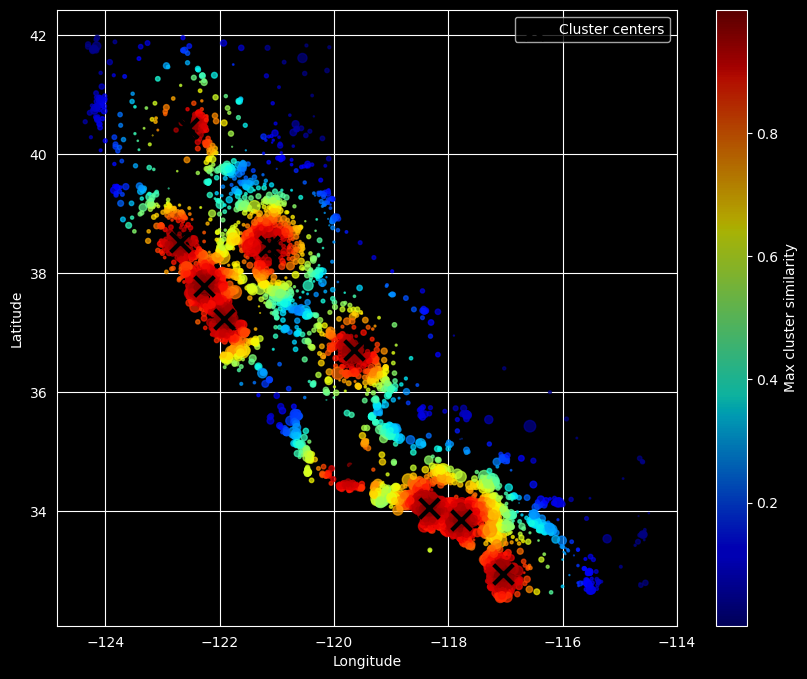

In [49]:
#Vibe Coded reproduction of plot in the book, showing centers of clusters as "X" and the color is representing similarity to the nearest cluster
import matplotlib.pyplot as plt
max_similarity = similarities.max(axis=1)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    housing["longitude"],
    housing["latitude"],
    c=max_similarity,        # color by max similarity
    cmap="jet",              # red=high, blue=low
    s=housing["population"] / 100,  # dot size = population
    alpha=0.7
)
# plot cluster centers as X markers
plt.scatter(
    cluster_simil.kmeans_.cluster_centers_[:, 1],  # longitude is column 1
    cluster_simil.kmeans_.cluster_centers_[:, 0],  # latitude is column 0
    marker="x",
    s=200,
    c="black",
    linewidths=3,
    label="Cluster centers"
)
plt.colorbar(scatter, label="Max cluster similarity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()